# ARTS ET METIERS - PGE2A - VIBRATIONS - ED1/2
## Free and Forced Response – 1DOF and 2DOF Systems

This notebook contains analytical and numerical tools to study:
- Free response of 1DOF systems
- Forced response in time and frequency domain
- Effect of damping
- Modal analysis of 2DOF systems

Contributed by E. Monteiro and E. Balmes  
Copyright (c) 2018-2026 by ENSAM, All Rights Reserved.


## Import useful libraries

In [1]:
import numpy as np
import scipy.integrate as integrate
import scipy.linalg as linalg
import matplotlib.pyplot as plot

from mevib import feeig, plot2D, plotFourier, plotFreq

## Part 0 – Predefined Functions

#### 1 DOF parameters

In [2]:
def compute_param_1DOF(pa):
    w0 = np.sqrt(pa['k']/pa['m'])
    xi = pa['c'] / (2.*np.sqrt(pa['k']*pa['m']))
    return w0, xi

#### Analytical Free Response formulas of 1 DOF System 

In [3]:
def FR_1DOF_formula(t, w0=1., xi=0.5, u0=5.0, v0=1.0):
    if xi < 1.:  # Underdamped
        wd = w0 * np.sqrt(1 - xi**2)
        return np.exp(-xi*w0*t) * (
            u0*np.cos(wd*t) + (v0 + xi*w0*u0)/wd * np.sin(wd*t)
        )
    elif xi == 1.:  # Critical damping
        return np.exp(-w0*t) * (u0 + (v0 + w0*u0)*t)
    else:  # Overdamped
        ws = w0 * np.sqrt(xi**2 - 1)
        return np.exp(-xi*w0*t) * (
            u0*np.cosh(ws*t) + (v0 + xi*w0*u0)/ws * np.sinh(ws*t)
        )

#### Analytical Free Response of 1 DOF System 

In [4]:
def FR_1DOF(pa, t=[]):
    w0, xi = compute_param_1DOF(pa)
    if len(t) == 0:
        t0 = 2.*np.pi / w0
        t = np.linspace(0, 10.*t0, 200)
    return FR_1DOF_formula(t, w0, xi, pa['u0'], pa['v0'])


#### Numerical Free Response of 1 DOF System via ODE Integration

In [5]:
def FR_1DOF_ODE(pa):

    if "A" not in pa: pa['A'] = np.array([[0, 1], [-pa['k']/pa['m'], -pa['c']/pa['m']]])

    if "x0" not in pa: pa['x0'] = [0, 1]

    odeFun = lambda t, x: pa['A'].dot(x)
    t_eval = np.linspace(0, pa['Tend'], int(np.ceil(pa['Tend']/pa['dt'])))

    sol = integrate.solve_ivp(
        odeFun, [0, pa['Tend']], pa['x0'],
        t_eval=t_eval, method='RK45' )

    C1 = dict([
        ('X', sol.t),
        ('Xlabel', 'Time (s)'),
        ('Y', np.transpose(sol.y)),
        ('Ylabel', 'Displacement (m)') ])    

    if "cobs" in pa:
        C1['Y'] = np.transpose(pa['cobs'].dot(sol.y))

    pa.setdefault('fmax', 1e10)
    pa.setdefault('tlim', [])

    plot2D(C1, gf=20, xlim=pa['tlim'])
    plotFourier(C1, gf=2, fmax=pa['fmax'])    

## Part 1 – System with 1 Degree of Freedom

#### Q2: State-Space Integration

In [6]:
def q2d():
    pa = dict([
        ('m', 1.), ('c', 0.2), ('k', 100),
        ('F0', 200.), ('a', 70.),
        ('u0', 1.), ('v0', 1.),
        ('Tend', 30.), ('dt', 0.05)
    ])
    FR_1DOF_ODE(pa)

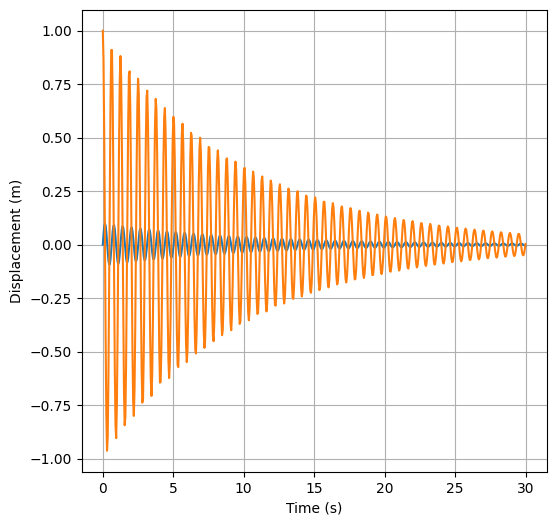

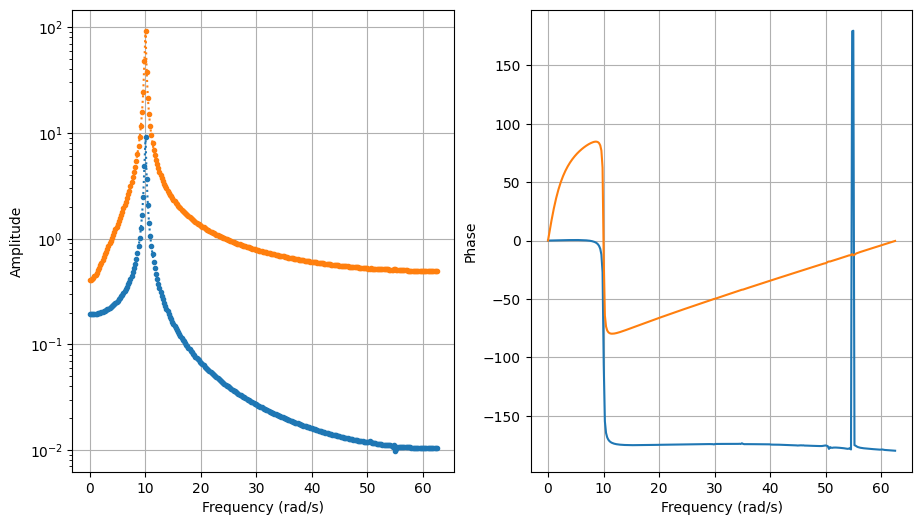

In [7]:
q2d()

#### Q3: Modal Transfer Function

In [8]:
def q3():
    pa = dict([
        ('m', 1.), ('c', .4), ('k', 400.),
        ('u0', 1.), ('v0', 1.),
        ('Tend', 10.), ('dt', 0.1)
    ])

    w0, xi = compute_param_1DOF(pa)

    xy = dict([
        ('X', np.linspace(0, w0*2, 100)),
        ('Xlabel', 'Frequency (rad/s)'),
        ('Y', ''),
        ('Ylabel', 'Displacement (m)')
    ])

    s = xy['X'] * 1j
    xy['Y'] = 1 / (pa['m']*s**2 + pa['c']*s + pa['k'])

    plotFreq(xy, gf=1)

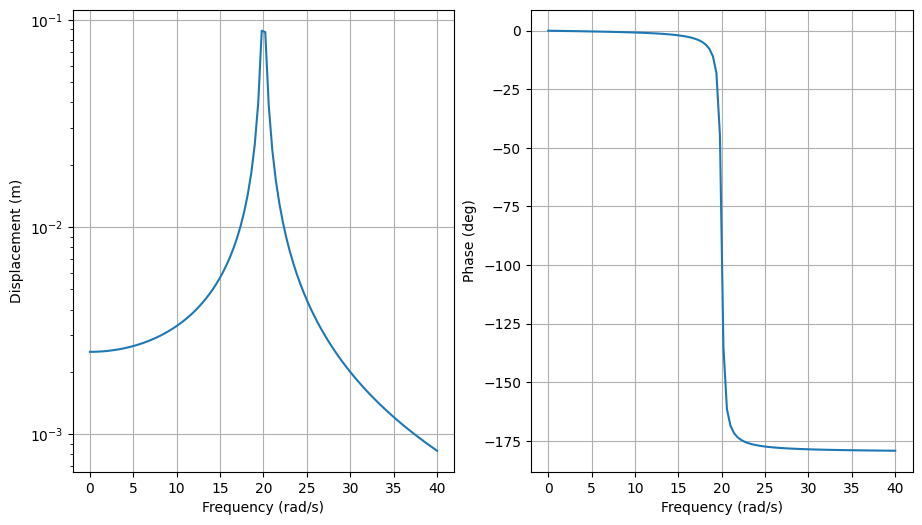

In [9]:
q3()

#### Q4: Damping Effect (Time)

In [10]:
def q4t():
    pa = dict([
        ('m', 1.), ('c', 0.5), ('k', 1.),
        ('u0', 1.), ('v0', 0.),
        ('Tend', 10.), ('dt', 0.1)
    ])

    val_xi = [0, 0.01, .7, 1.0, 4.0]

    xyplot = dict([
        ('X', np.linspace(0, pa['Tend'], int(np.ceil(pa['Tend']/pa['dt'])))),
        ('Xlabel', 'Time (s)'),
        ('Y', ''),
        ('Ylabel', 'Displacement (m)'),
        ('legend', val_xi)
    ])

    xyplot['Y'] = np.zeros((len(xyplot['X']), len(val_xi)))

    for j, xi in enumerate(val_xi):
        pa['c'] = xi * (2*np.sqrt(pa['k']*pa['m']))
        xyplot['Y'][:, j] = FR_1DOF(pa, xyplot['X'])

    plot2D(xyplot, gf=20)


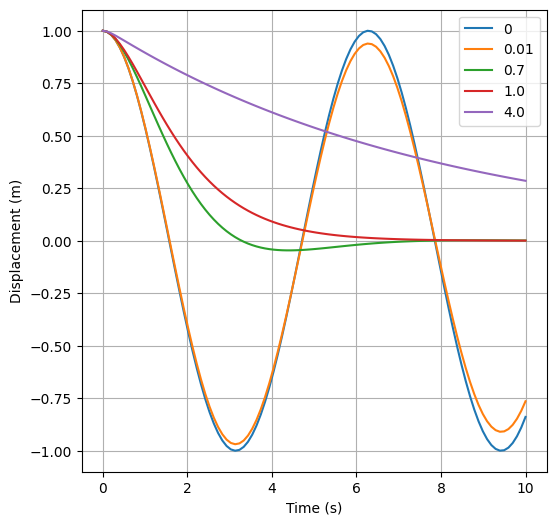

In [11]:
q4t()

## Part 2 – System with 2 Degrees of Freedom


#### Q7b: Modal Analysis

In [12]:
def q7b(nout=0):
    pb = dict([
        ('m', 1500.), ('a', 1.2), ('b', 1.4),
        ('ka', []), ('kb', []), ('k0', 40e3),
        ('u0', [1., 0.]), ('v0', [1., 0.]),
        ('balanced', 1)
    ])

    if pb['balanced'] == 1:
        pb['ka'] = (pb['a'] + pb['b'])/pb['a'] * pb['k0']
        pb['kb'] = (pb['a'] + pb['b'])/pb['b'] * pb['k0']

    M = np.array([
        [pb['m'], 0],
        [0, pb['m']*(pb['a']+pb['b'])**2/2]
    ])

    K = np.array([
        [pb['ka']+pb['kb'], -pb['a']*pb['ka']+pb['b']*pb['kb']],
        [-pb['a']*pb['ka']+pb['b']*pb['kb'],
         pb['ka']*pb['a']**2 + pb['kb']*pb['b']**2]
    ])

    vals, vecs = feeig(K, M)

    if nout == 0:
        print("Eigenvalues (Hz):", vals / (2*np.pi))
    else:
        return pb, vals, vecs, M, K


In [13]:
q7b()

Eigenvalues (Hz): [1.16230337 1.64863002]


#### Q7d: Forced Response (2 DOF)

In [ ]:
def q7d(nout=0):
    # On paper: normalize modes, express transfer, add modal damping
    pb, vals, vecs, M, K = q7b(nout=1)

    # Add damping (proportional to stiffness)
    C = 1e-3 * K
    if nout == 0: print("C = ", C)

    # State-space matrices
    pb['A'] = np.block([
        [np.zeros((2, 2)), np.eye(2)],
        [linalg.solve(M, -K), linalg.solve(M, -C)]
    ])

    pb['B'] = np.block([
        [np.zeros((2, 1))],
        [linalg.solve(M, np.array([[1.], [0.]]))]
    ])

    # Simulation parameters
    pb['Tend'] = 200
    pb['dt'] = 1e-2
    pb['x0'] = [1., 0.1, 0., 0.]
    pb['cobs'] = np.array([[1, 1, 0, 0]])
    pb['fmax'] = 30 / (2*np.pi)

    if nout == 0:
        FR_1DOF_ODE(pb)
    else:
        return pb, vals, vecs, M, K


C =  [[160.95238095   0.        ]
 [  0.         270.4       ]]


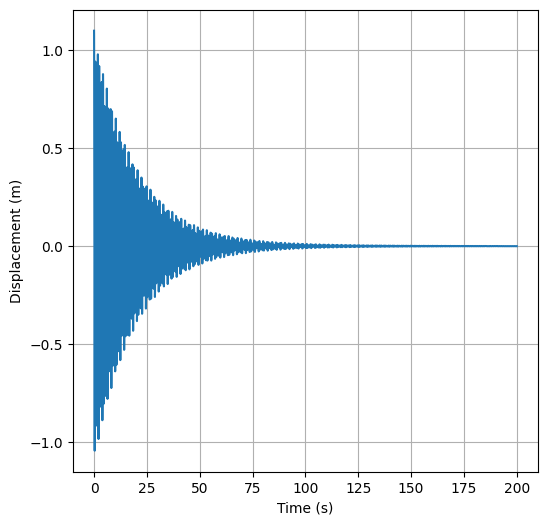

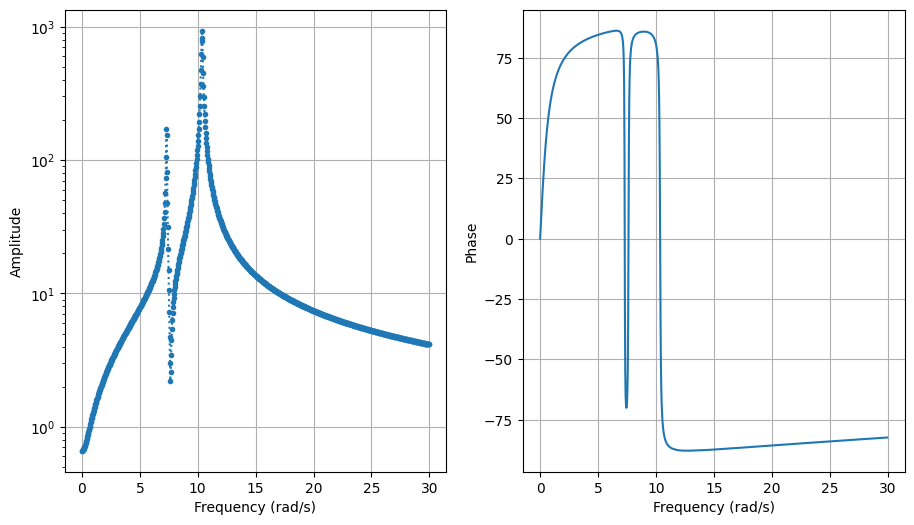

In [15]:
q7d()

#### Q7e: Modal Amplitudes (Time & Frequency)

In [ ]:
def q7e():
    # Build matrices and compute modes
    pb, vals, vecs, M, K = q7d(nout=1)

    # Modal mass checks
    un1 = vecs[:, 0].T @ M @ vecs[:, 0]
    un2 = vecs[:, 1].T @ M @ vecs[:, 1]
    un3 = vecs[:, 0].T @ M @ vecs[:, 1]

    print('? = ', un1, un2, un3)  # Expected: un1 ≈ un2 ≈ 1, un3 ≈ 0

    # Modal observation matrix
    pb['cobs'] = np.array([
        np.concatenate((vecs[:, 0].T @ M, np.array([0, 0])), axis=0),
        np.concatenate((vecs[:, 1].T @ M, np.array([0, 0])), axis=0)
    ])

    pb['fmax'] = 30 / (2*np.pi)
    pb['tlim'] = np.array([0, 10])

    # Analyze time (figure 20) and frequency (figure 2)
    FR_1DOF_ODE(pb)

? =  1.0000000000000002 1.0 0.0


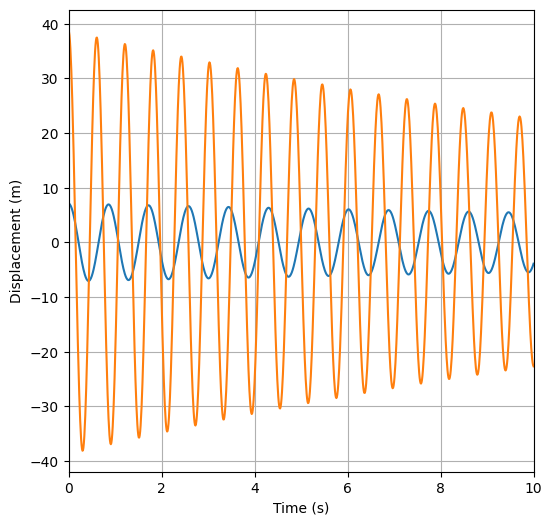

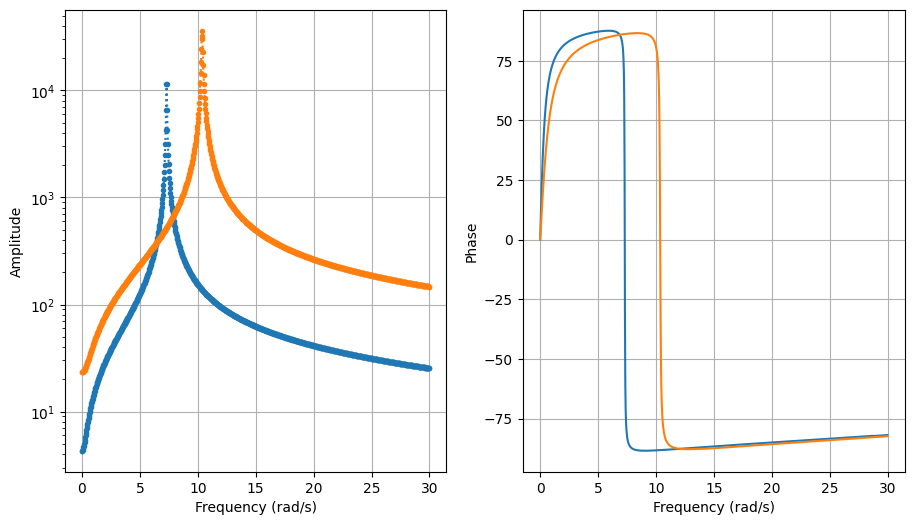

In [17]:
q7e()